In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

np.random.seed(42)

In [ ]:
df = pd.read_csv('air_quality_data.csv')
df.describe()

,PM25_ugm3,CO_ppm,NO2_ppb,O3_ppb,SO2_ppb,Temperature_C,Humidity,WindSpeed_ms,AQI
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,68.991707,1.126097,73.896745,59.659579,6.192821,15.528024,46.787774,6.050360,50.374081
std,39.521103,0.564139,25.016806,25.187067,2.634858,11.638852,19.335416,2.744414,18.393589
min,26.217000,0.511000,39.654000,5.000000,1.213000,-22.366000,5.000000,0.300000,0.000000
25%,47.049000,0.840750,60.517000,40.538500,4.299500,7.853000,33.292750,4.250250,38.248500
50%,58.553500,1.021500,69.920000,59.675500,5.818000,15.542500,46.624000,5.760500,48.738000
75%,78.262250,1.240250,81.374250,78.594000,7.606500,23.172750,60.026000,7.594500,59.724000
max,478.488000,7.104000,306.894000,130.427000,22.509000,47.651000,95.000000,15.000000,169.900000


In [ ]:
df.head()

,PM25_ugm3,CO_ppm,NO2_ppb,O3_ppb,SO2_ppb,Temperature_C,Humidity,WindSpeed_ms,AQI
0,42.918,1.004,69.971,56.767,7.803,19.689,73.333,8.767,39.068
1,43.599,0.788,66.189,77.334,8.436,28.071,45.645,6.638,23.578
2,54.738,1.625,74.835,67.327,7.617,9.203,49.427,10.607,68.181
3,147.763,1.383,81.405,43.321,5.718,4.932,51.096,7.959,56.705
4,60.479,0.873,70.216,38.652,7.302,25.370,58.998,9.078,48.963


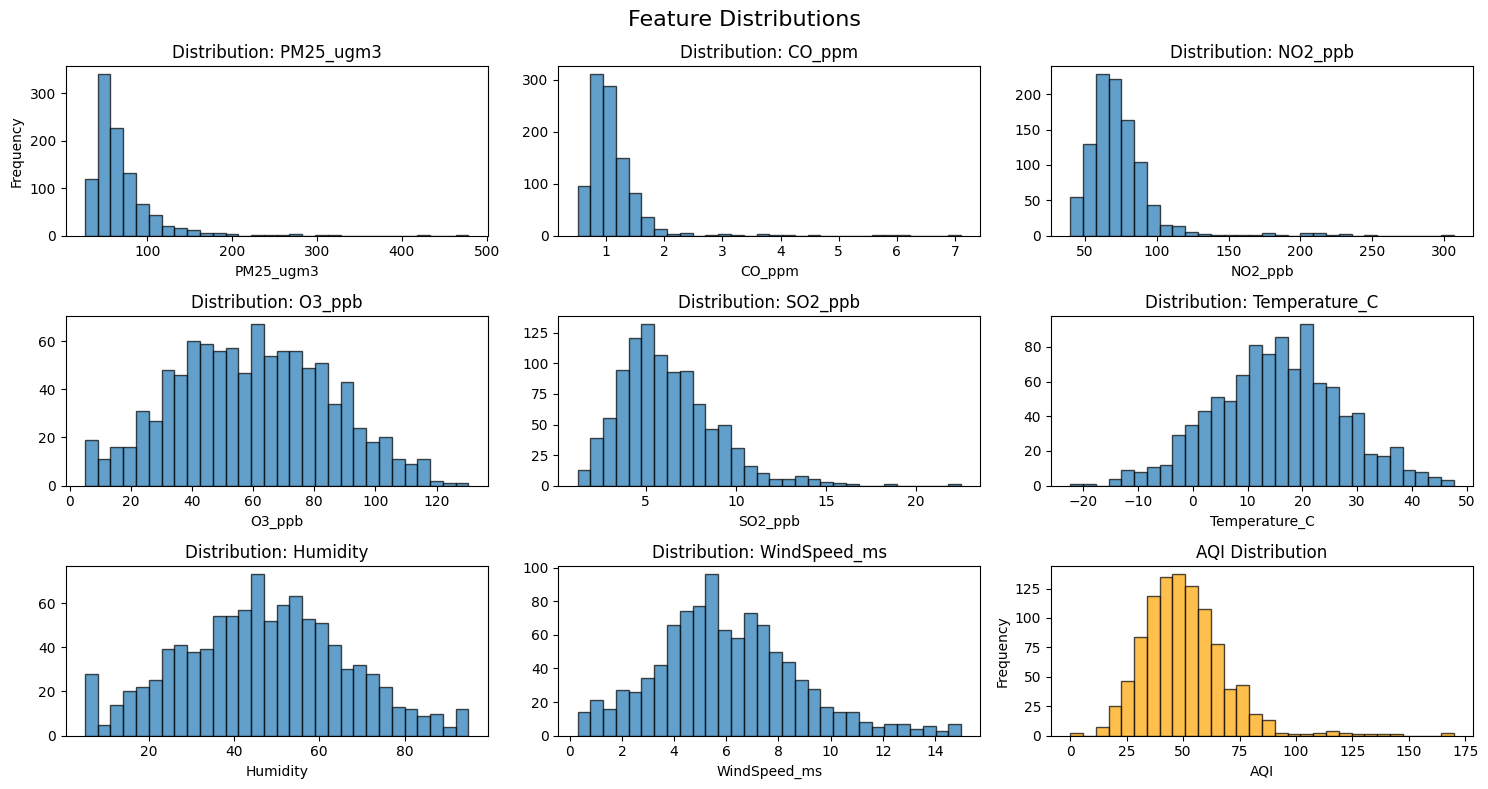

In [ ]:
# Visualize feature scales
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
features = ['PM25_ugm3', 'CO_ppm', 'NO2_ppb', 'O3_ppb', 'SO2_ppb', 'Temperature_C', 'Humidity', 'WindSpeed_ms']
for idx, feature in enumerate(features):
    ax = axes[idx//3, idx%3]
    ax.hist(df[feature], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution: {feature}')
    ax.set_xlabel(feature)
    if idx == 0:
        ax.set_ylabel('Frequency')

ax = axes[2, 2]
ax.hist(df['AQI'], bins=30, edgecolor='black', alpha=0.7, color='orange')
ax.set_title('AQI Distribution')
ax.set_xlabel('AQI')
ax.set_ylabel('Frequency')

fig.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

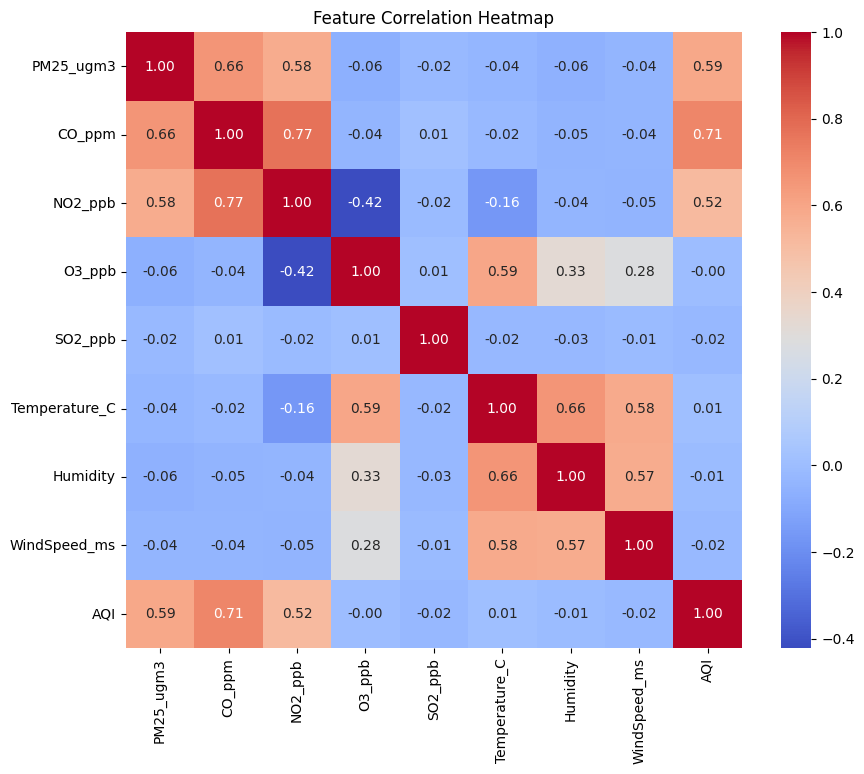

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# Create feature matrix and target
X = df[features].values
y = df['AQI'].values

## Task 1

In [ ]:
# lr on raw features
lr_raw = LinearRegression()
lr_raw.fit(X, y)

# lr on standardized features
lr_standardized = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])
lr_standardized.fit(X, y)

# Coefficient table
coef_table = [
    [feat, c_raw, c_std] for feat, c_raw, c_std in zip(features, lr_raw.coef_, lr_standardized.named_steps['lr'].coef_)
]

print("OLS Coefficients Comparison:")
print(tabulate(
    coef_table,
    headers=["Feature", "Coef (Raw)", "Coef (Standardized)"],
    tablefmt="github",
    floatfmt=".3f"
))

OLS Coefficients Comparison:
| Feature       |   Coef (Raw) |   Coef (Standardized) |
|---------------|--------------|-----------------------|
| PM25_ugm3     |        0.110 |                 4.343 |
| CO_ppm        |       22.110 |                12.467 |
| NO2_ppb       |       -0.118 |                -2.945 |
| O3_ppb        |       -0.034 |                -0.851 |
| SO2_ppb       |       -0.209 |                -0.551 |
| Temperature_C |        0.010 |                 0.121 |
| Humidity      |        0.044 |                 0.857 |
| WindSpeed_ms  |       -0.056 |                -0.153 |


If you calculate the MSE, it will be exactly same, as the model is invariant to feature scaling

You should also observe, coeffs are much higher for CO compared to other features in standard lr, while after normalisation, some other features look reasonably important too. 

## Task 2

In [ ]:
lambdas_ridge = np.logspace(-2, 3, 50)  # More points for smooth paths
ridge_raw_coefs = []

for lam in lambdas_ridge:
    ridge_raw = Ridge(alpha=lam, random_state=42)
    ridge_raw.fit(X, y)
    ridge_raw_coefs.append(ridge_raw.coef_)

ridge_raw_coefs = np.array(ridge_raw_coefs)

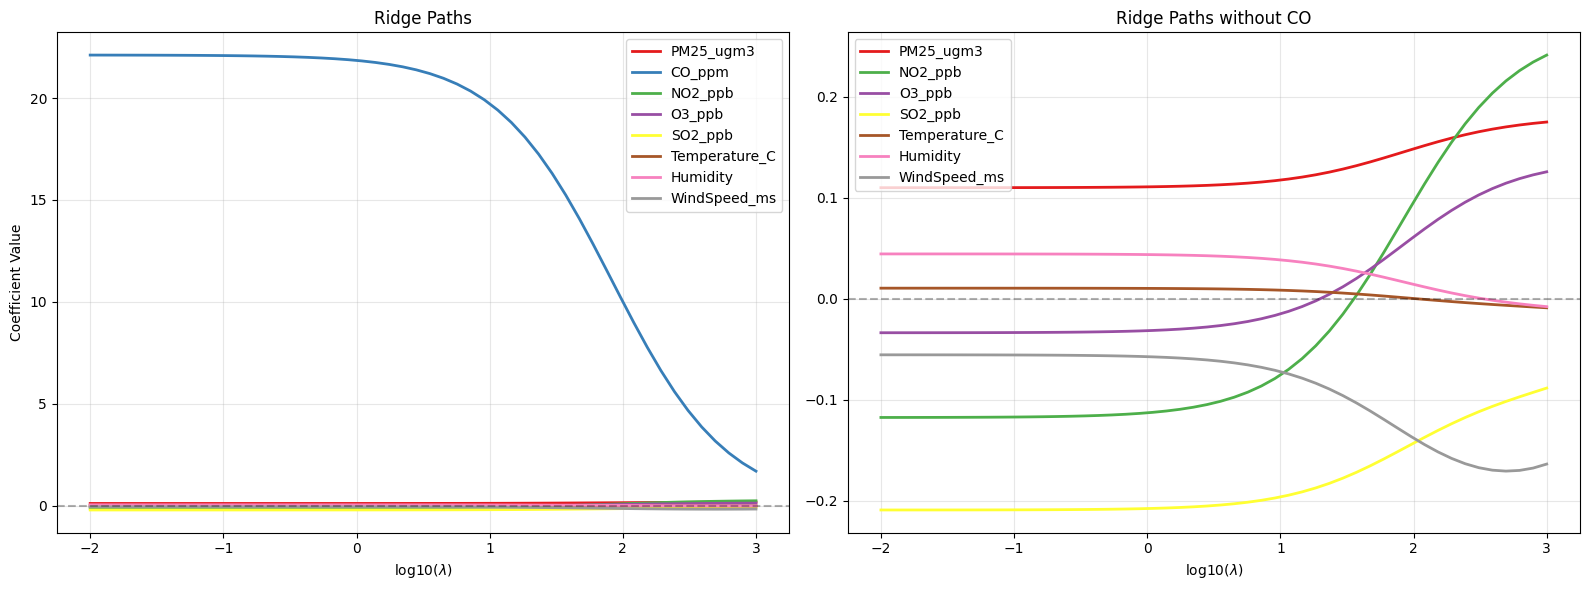

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
colors = plt.cm.Set1(np.linspace(0, 1, len(features)))

for i, feature in enumerate(features):
    axes[0].plot(np.log10(lambdas_ridge), ridge_raw_coefs[:, i], color=colors[i], linewidth=2, label=feature)

axes[0].set_xlabel('log10($\\lambda$)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge Paths')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')


for i, feature in enumerate(features):
    if feature == 'CO_ppm':
        continue

    axes[1].plot(np.log10(lambdas_ridge), ridge_raw_coefs[:, i], color=colors[i], linewidth=2, label=feature)

axes[1].set_xlabel('log10($\\lambda$)')
axes[1].set_title('Ridge Paths without CO')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()


As we see, the feature which had the smallest std-dev changes the most as regularisation increases

We can also see coefficients of some features increasing as regularisation increases

## Task 3

In [ ]:
ridge_std_coefs = []

for lam in lambdas_ridge:
    ridge_std = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=lam, random_state=42))])
    ridge_std.fit(X, y)
    ridge_std_coefs.append(ridge_std.named_steps['ridge'].coef_)

ridge_std_coefs = np.array(ridge_std_coefs)

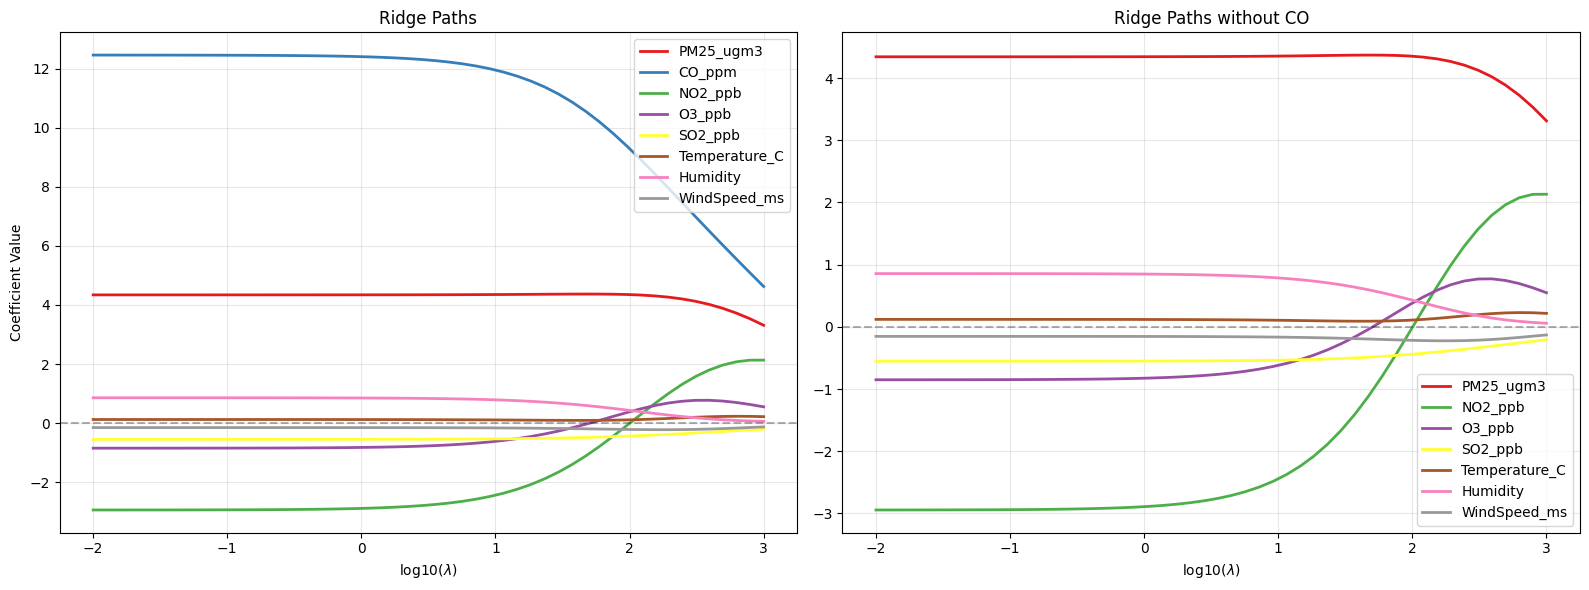

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
colors = plt.cm.Set1(np.linspace(0, 1, len(features)))

for i, feature in enumerate(features):
    axes[0].plot(np.log10(lambdas_ridge), ridge_std_coefs[:, i], color=colors[i], linewidth=2, label=feature)

axes[0].set_xlabel('log10($\\lambda$)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge Paths')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')


for i, feature in enumerate(features):
    if feature == 'CO_ppm':
        continue

    axes[1].plot(np.log10(lambdas_ridge), ridge_std_coefs[:, i], color=colors[i], linewidth=2, label=feature)

axes[1].set_xlabel('log10($\\lambda$)')
axes[1].set_title('Ridge Paths without CO')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()


Coefficients now shrink at more similar rates, and no single feature dominates the scale of the plot. The regularization paths become more comparable across variables, reflecting predictive contribution rather than measurement units.

At $\lambda=10$, order of magnitude of coefficients tells us the order of importance of features.

## Task 4

In [ ]:
lambdas_lasso = np.logspace(-2, 3, 50)  # More points for smooth paths
lasso_raw_coefs = []

for lam in lambdas_lasso:
    lasso = Lasso(alpha=lam, max_iter=10000, random_state=42)
    lasso.fit(X, y)
    lasso_raw_coefs.append(lasso.coef_)

lasso_raw_coefs = np.array(lasso_raw_coefs)

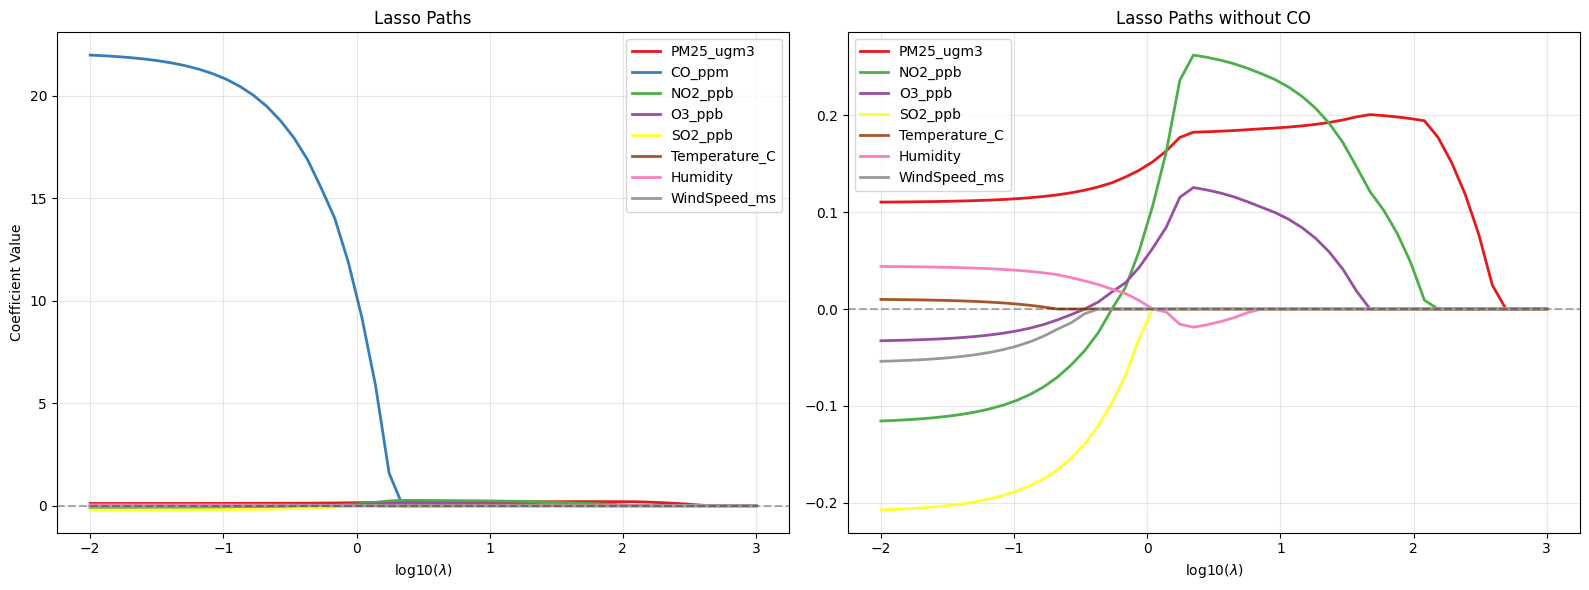

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
colors = plt.cm.Set1(np.linspace(0, 1, len(features)))

for i, feature in enumerate(features):
    axes[0].plot(np.log10(lambdas_lasso), lasso_raw_coefs[:, i], color=colors[i], linewidth=2, label=feature)

axes[0].set_xlabel('log10($\\lambda$)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Lasso Paths')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')


for i, feature in enumerate(features):
    if feature == 'CO_ppm':
        continue

    axes[1].plot(np.log10(lambdas_lasso), lasso_raw_coefs[:, i], color=colors[i], linewidth=2, label=feature)

axes[1].set_xlabel('log10($\\lambda$)')
axes[1].set_title('Lasso Paths without CO')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()


In [ ]:
# Feature entry table
entry_lambda_raw = {}
for i, name in enumerate(features):
    nonzero = np.where(lasso_raw_coefs[:, i] != 0)[0]
    entry_lambda_raw[name] = lambdas_lasso[nonzero[-1]] if len(nonzero) > 0 else None

print("\nLasso feature entry (raw data):")
print(tabulate(
    [[feat, f"{entry_lambda_raw[feat]:.3e}" if entry_lambda_raw[feat] is not None else "Never"] for feat in features],
    headers=["Feature", "Entry Lambda"],
    tablefmt="github"
))


Lasso feature entry (raw data):
| Feature       |   Entry Lambda |
|---------------|----------------|
| PM25_ugm3     |       390.7    |
| CO_ppm        |         1.758  |
| NO2_ppb       |       120.7    |
| O3_ppb        |        37.28   |
| SO2_ppb       |         0.8685 |
| Temperature_C |         0.1677 |
| Humidity      |         5.69   |
| WindSpeed_ms  |         0.3393 |


We can see that PM25 enters the first

## Task 5

In [ ]:
lasso_std_coefs = []

for lam in lambdas_lasso:
    lasso = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(alpha=lam, max_iter=10000, random_state=42))])
    lasso.fit(X, y)
    lasso_std_coefs.append(lasso.named_steps['lasso'].coef_)

lasso_std_coefs = np.array(lasso_std_coefs)

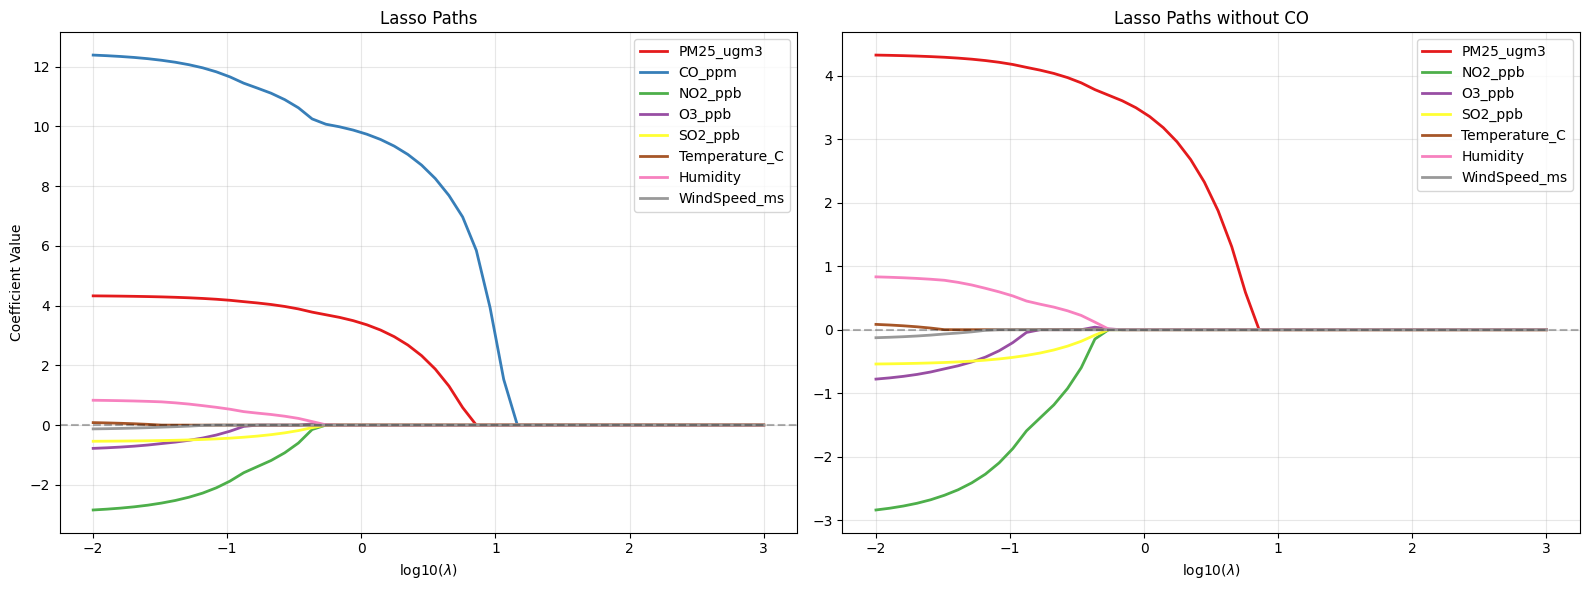

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
colors = plt.cm.Set1(np.linspace(0, 1, len(features)))

for i, feature in enumerate(features):
    axes[0].plot(np.log10(lambdas_lasso), lasso_std_coefs[:, i], color=colors[i], linewidth=2, label=feature)

axes[0].set_xlabel('log10($\\lambda$)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Lasso Paths')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')


for i, feature in enumerate(features):
    if feature == 'CO_ppm':
        continue

    axes[1].plot(np.log10(lambdas_lasso), lasso_std_coefs[:, i], color=colors[i], linewidth=2, label=feature)

axes[1].set_xlabel('log10($\\lambda$)')
axes[1].set_title('Lasso Paths without CO')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()


We can see that CO and PM25 are consistently picked, while O3, temperature, windspeed are never picked.

In [ ]:
# Feature entry table
entry_lambda_std = {}
for i, name in enumerate(features):
    nonzero = np.where(lasso_std_coefs[:, i] != 0)[0]
    entry_lambda_std[name] = lambdas_lasso[nonzero[-1]] if len(nonzero) > 0 else None

print("\nLasso feature entry (standardised data):")
print(tabulate(
    [[feat, f"{entry_lambda_std[feat]:.3e}" if entry_lambda_std[feat] is not None else "Never"] for feat in features],
    headers=["Feature", "Entry Lambda"],
    tablefmt="github"
))


Lasso feature entry (standardised data):
| Feature       |   Entry Lambda |
|---------------|----------------|
| PM25_ugm3     |        5.69    |
| CO_ppm        |       11.51    |
| NO2_ppb       |        0.4292  |
| O3_ppb        |        0.5429  |
| SO2_ppb       |        0.4292  |
| Temperature_C |        0.03237 |
| Humidity      |        0.5429  |
| WindSpeed_ms  |        0.06551 |


With raw data: PM25 → NO2 → O3 → ...  
With normalized data: CO → PM25 → ...

Hence, the order completely changes

In [ ]:
lam_comparison = 0.5
lam_idx = np.argmin(np.abs(lambdas_lasso - lam_comparison))

comparison = []
for i, feature in enumerate(features):
    raw_selected = np.abs(lasso_raw_coefs[lam_idx, i]) > 1e-6
    std_selected = np.abs(lasso_std_coefs[lam_idx, i]) > 1e-6
    
    comparison.append({
        'Feature': feature,
        'Raw_Selected': 'Yes' if raw_selected else 'No',
        'Std_Selected': 'Yes' if std_selected else 'No',
        'Raw_Coeff': lasso_raw_coefs[lam_idx, i],
        'Std_Coeff': lasso_std_coefs[lam_idx, i],
        'Disagreement': 'Yes' if raw_selected != std_selected else 'No'
    })

print(f"\nFeature Selection at λ = {lam_comparison}:")
print(tabulate(
    [[c['Feature'], c['Raw_Selected'], c['Std_Selected'], f"{c['Raw_Coeff']:.3f}", f"{c['Std_Coeff']:.3f}", c['Disagreement']] for c in comparison],
    headers=["Feature", "Selected (Raw)", "Selected (Std)", "Coef (Raw)", "Coef (Std)", "Disagreement"],
    tablefmt="github"
))


Feature Selection at λ = 0.5:
| Feature       | Selected (Raw)   | Selected (Std)   |   Coef (Raw) |   Coef (Std) | Disagreement   |
|---------------|------------------|------------------|--------------|--------------|----------------|
| PM25_ugm3     | Yes              | Yes              |        0.13  |        3.695 | No             |
| CO_ppm        | Yes              | Yes              |       15.502 |       10.075 | No             |
| NO2_ppb       | No               | No               |       -0     |       -0     | No             |
| O3_ppb        | Yes              | Yes              |        0.018 |        0.011 | No             |
| SO2_ppb       | Yes              | No               |       -0.097 |       -0     | Yes            |
| Temperature_C | No               | No               |        0     |        0     | No             |
| Humidity      | Yes              | Yes              |        0.021 |        0.01  | No             |
| WindSpeed_ms  | No               | No   

## Task 6

In [ ]:
# Find top 10 PM25 and CO values
top_pm25_idx = np.argsort(X[:, 0])[-10:]
top_co_idx = np.argsort(X[:, 1])[-10:]

print(f"Top 10 PM25 values: {X[top_pm25_idx, 0]}")
print(f"Top 10 CO values: {X[top_co_idx, 1]}")

# Check if same samples
common = np.intersect1d(top_pm25_idx, top_co_idx)
print(f"{len(common)} samples are in both lists (same outliers)")
print("\n")

pm25_outliers = df["PM25_ugm3"] > 200
co_outliers = df["CO_ppm"] > 3

print("\nPM2.5 outliers (> 200):", pm25_outliers.sum())
print("CO outliers (> 3):", co_outliers.sum())
print("Overlap:", (pm25_outliers & co_outliers).sum())

Top 10 PM25 values: [237.301 265.056 269.349 274.205 279.202 305.527 316.591 419.335 432.707
 478.488]
Top 10 CO values: [3.938 4.001 4.098 4.207 4.491 5.6   5.851 5.931 6.143 7.104]
6 samples are in both lists (same outliers)



PM2.5 outliers (> 200): 14
CO outliers (> 3): 19
Overlap: 11


In [ ]:
# Dataset A: remove outliers + normalize
df_A = df[~(pm25_outliers | co_outliers)]
X_A = df_A[features].values
y_A = df_A['AQI'].values

In [ ]:
lambda_ridge = 10

ridge_plain = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=lambda_ridge, random_state=42))
])
ridge_plain.fit(X, y)
ridge_plain = ridge_plain.named_steps['ridge']

ridge_outlier_removed = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=lambda_ridge, random_state=42))
])
ridge_outlier_removed.fit(X_A, y_A)
ridge_A = ridge_outlier_removed.named_steps['ridge']

ridge_robust = Pipeline([
    ('scaler', RobustScaler()),
    ('ridge', Ridge(alpha=lambda_ridge, random_state=42))
])
ridge_robust.fit(X, y)
ridge_B = ridge_robust.named_steps['ridge']

coef_comparison = []
for i, feature in enumerate(features):
    coef_plain = ridge_plain.coef_[i]
    coef_A = ridge_A.coef_[i]
    coef_B = ridge_B.coef_[i]
    coef_comparison.append({
        'Feature': feature,
        'Plain Ridge Coeff': coef_plain,
        'Ridge_A_Coeff': coef_A,
        'Ridge_B_Coeff': coef_B,
    })

print(f"\nRidge Coefficients Comparison at lambda = {lambda_ridge}:")
print(tabulate(
    [[c['Feature'], f"{c['Plain Ridge Coeff']:.3f}", f"{c['Ridge_A_Coeff']:.3f}", f"{c['Ridge_B_Coeff']:.3f}"] for c in coef_comparison],
    headers=["Feature", "Plain Ridge Coeff", "Ridge_A Coeff", "Ridge_B Coeff"],
    tablefmt="github"
))


Ridge Coefficients Comparison at lambda = 10:
| Feature       |   Plain Ridge Coeff |   Ridge_A Coeff |   Ridge_B Coeff |
|---------------|---------------------|-----------------|-----------------|
| PM25_ugm3     |               4.354 |           3.874 |           3.425 |
| CO_ppm        |              11.959 |           9.726 |           8.625 |
| NO2_ppb       |              -2.444 |          -0.771 |          -2.195 |
| O3_ppb        |              -0.619 |           0.392 |          -1.039 |
| SO2_ppb       |              -0.535 |          -0.596 |          -0.675 |
| Temperature_C |               0.107 |          -0.6   |           0.139 |
| Humidity      |               0.787 |           0.791 |           1.101 |
| WindSpeed_ms  |              -0.165 |          -0.312 |          -0.183 |


We can see that the most stable approach is Robust scaling, as itis less affected by extreme values and preserves more data than outlier removal